In [62]:
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse

## 0. Data Collection 

In [63]:
# ！！！Original code to get data. As this is time-consuming, I already saved it as "HMDA_CA_TX_2019_2024_Master.csv". And you donot 
# need to run this cell for further steps. 
# print("Starting the [CA+TX] Data Engine (2019-2024)...")

# # 1. set years to 2019-2024
# years = ['2019', '2020', '2021', '2022', '2023', '2024']
# target_states = "CA,TX"

# # 2. Proportional Stratified Sampling Rate
# # By applying the EXACT SAME fraction (1%) to both classes independently, 
# # we mathematically guarantee Proportional Stratified Sampling.
# # This ensures the final dataset perfectly maintains the real-world ratio of Approved vs Denied.
# SAMPLE_FRACTION = 0.01 

# all_sampled_data = []

# for year in years:
#     print(f"\n ================= Fetching {year} ================= ")
    
#     # ---------------------------------------------------------
#     # Stratum 1: Originated Loans (Approved)
#     # ---------------------------------------------------------
#     url_originated = f"https://ffiec.cfpb.gov/v2/data-browser-api/view/csv?states={target_states}&years={year}&actions_taken=1"
#     try:
#         df_1 = pd.read_csv(url_originated, low_memory=False)
#         # Apply stratified sampling for Stratum 1
#         df_1 = df_1.sample(frac=SAMPLE_FRACTION, random_state=42)
#         # Manually assign the positive label (1 = Approved)
#         df_1['target_y'] = 1  
#         all_sampled_data.append(df_1)
#         print(f"Stratum 1 (Approved): Sampled {len(df_1):,} rows.")
        
#         # Free up memory
#         del df_1
#         gc.collect()
#     except Exception as e:
#         print(f"Failed to fetch Stratum 1 data for {year}: {e}")
        
#     # ---------------------------------------------------------
#     # Stratum 2: Denied Loans
#     # ---------------------------------------------------------
#     url_denied = f"https://ffiec.cfpb.gov/v2/data-browser-api/view/csv?states={target_states}&years={year}&actions_taken=3"
#     try:
#         df_3 = pd.read_csv(url_denied, low_memory=False)
#         # Apply stratified sampling for Stratum 2 using the SAME fraction
#         df_3 = df_3.sample(frac=SAMPLE_FRACTION, random_state=42)
#         # Manually assign the negative label (0 = Denied)
#         df_3['target_y'] = 0  
#         all_sampled_data.append(df_3)
#         print(f"Stratum 2 (Denied): Sampled {len(df_3):,} rows.")
        
#         # Free up memory
#         del df_3
#         gc.collect()
#     except Exception as e:
#         print(f" Failed to fetch Stratum 2 data for {year}: {e}")

# print("\n🔄 Merging all strata and years into the final Master dataset...")
# # Concatenate all datasets
# final_df = pd.concat(all_sampled_data, ignore_index=True)

# print("\n🏆 --- Final Master Dataset Statistics ---")
# print(f"Total rows: {len(final_df):,}")
# print("\nTarget Distribution (Perfectly mirrors reality due to Stratified Sampling):")
# print(final_df['target_y'].value_counts(normalize=True))

# # Export the master dataset
# final_df.to_csv("HMDA_CA_TX_2019_2024_Master.csv", index=False)
# print("\n Success! Dataset saved as 'HMDA_CA_TX_2019_2024_Master.csv'")

## 1. Rough EDA + Cleaning

#### read raw data

In [64]:
final_df = pd.read_csv("HMDA_CA_TX_2019_2024_Master.csv", low_memory=False)
print(final_df.shape)
print(final_df.head(3))

(139991, 100)
   activity_year                   lei  derived_msa-md state_code  \
0           2019  KB1H1DSPRFMYMCUFXT09           44700         CA   
1           2019  5493001SXWZ4OFP8Z903           26420         TX   
2           2019  7H6GLXDRUGQFU57RNE97           41700         TX   

   county_code  census_tract conforming_loan_limit derived_loan_product_type  \
0       6077.0  6.077001e+09                     C   Conventional:First Lien   
1      48201.0  4.820154e+10                     C            FHA:First Lien   
2      48029.0  4.802912e+10                     C   Conventional:First Lien   

              derived_dwelling_category       derived_ethnicity  ...  \
0  Single Family (1-4 Units):Site-Built      Hispanic or Latino  ...   
1  Single Family (1-4 Units):Site-Built      Hispanic or Latino  ...   
2  Single Family (1-4 Units):Site-Built  Not Hispanic or Latino  ...   

  denial_reason-3 denial_reason-4  tract_population  \
0             NaN             NaN           

In [65]:
print(list(final_df.columns))

['activity_year', 'lei', 'derived_msa-md', 'state_code', 'county_code', 'census_tract', 'conforming_loan_limit', 'derived_loan_product_type', 'derived_dwelling_category', 'derived_ethnicity', 'derived_race', 'derived_sex', 'action_taken', 'purchaser_type', 'preapproval', 'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread', 'hoepa_status', 'total_loan_costs', 'total_points_and_fees', 'origination_charges', 'discount_points', 'lender_credits', 'loan_term', 'prepayment_penalty_term', 'intro_rate_period', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'property_value', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'total_units', 'multifamily_affordable_units', 'income', 'debt_to_income_ratio', 'applicant_credit_score

## 1.1. Dtype Formatting

In [66]:
df_final = final_df.copy()

# Drop obvious label-leakage / post-outcome fields if present
leakage_cols = ['action_taken', 'purchaser_type', 'denial_reason-1', 'denial_reason-2', 'denial_reason-3', 'denial_reason-4']
df_final = df_final.drop(columns=[c for c in leakage_cols if c in df_final.columns], errors='ignore')

def get_covid_phase(year):
    try:
        year_float = float(year)
        if pd.isna(year_float):
            return np.nan
        if year_float <= 2019:
            return 'Pre-Pandemic'
        if year_float <= 2021:
            return 'Peak-Pandemic'
        return 'Post-Pandemic'
    except (TypeError, ValueError):
        return np.nan

if 'activity_year' in df_final.columns:
    df_final['covid_phase'] = df_final['activity_year'].apply(get_covid_phase)
    df_final = df_final.drop(columns=['activity_year'])
    print("✅ 'activity_year' converted to 'covid_phase' and dropped.")

numeric_cols = [
    'loan_amount',
    'loan_to_value_ratio',
    'interest_rate',
    'rate_spread',
    'total_loan_costs',
    'origination_charges',
    'discount_points',
    'lender_credits',
    'property_value',
    'income',
    'tract_population',
    'tract_minority_population_percent',
    'ffiec_msa_md_median_family_income',
    'tract_to_msa_income_percentage',
    'tract_owner_occupied_units',
    'tract_one_to_four_family_homes',
    'tract_median_age_of_housing_units',
]

if 'target_y' in df_final.columns:
    df_final['target_y'] = pd.to_numeric(df_final['target_y'], errors='coerce').astype('Int8')

for col in numeric_cols:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

categorical_cols = [c for c in df_final.columns if c not in numeric_cols and c != 'target_y']
for col in categorical_cols:
    df_final[col] = (
        df_final[col]
        .astype('string')
        .replace({'nan': pd.NA, 'NaN': pd.NA, 'None': pd.NA})
    )

final_df = df_final

✅ 'activity_year' converted to 'covid_phase' and dropped.


## 1.2. find & drop cols with high missing rate

In [67]:
# 1. find data with High Missing Rates

print("Finding features with High Missing Values (>80% missing)")
missing_pct = final_df.isnull().mean() * 100
high_missing_cols = missing_pct[missing_pct > 80].sort_values(ascending=False)
print(high_missing_cols)
print(" We will drop these columns because they lack sufficient data to train a robust model. Filling them would introduce massive bias.\n")

Finding features with High Missing Values (>80% missing)
co-applicant_ethnicity-4        99.998571
co-applicant_ethnicity-5        99.998571
applicant_ethnicity-5           99.997857
applicant_ethnicity-4           99.995714
co-applicant_race-5             99.995714
applicant_race-5                99.982856
co-applicant_race-4             99.973570
co-applicant_ethnicity-3        99.944282
applicant_race-4                99.939282
applicant_ethnicity-3           99.829989
co-applicant_race-3             99.741412
aus-5                           99.391389
applicant_race-3                99.346387
aus-4                           99.310670
multifamily_affordable_units    98.412041
aus-3                           98.227743
total_points_and_fees           97.569844
prepayment_penalty_term         96.106893
co-applicant_race-2             95.879735
co-applicant_ethnicity-2        95.492567
aus-2                           91.633748
applicant_race-2                90.462244
applicant_ethnicity

In [68]:
# Extract the column names (the keys of the Series) that have >80% missing values
cols_to_drop_missing = high_missing_cols.index.tolist()

print(f"🗑️ Dropping {len(cols_to_drop_missing)} columns due to >80% missing rates...")

# Drop them from the dataframe
# Using inplace=False (default) and assigning it to df_cleaned to keep the original final_df safe
df_cleaned = final_df.drop(columns=cols_to_drop_missing)

print(f"✅ Drop successful!")
print(f"Original columns: {final_df.shape[1]}")
print(f"Remaining columns: {df_cleaned.shape[1]}")

🗑️ Dropping 24 columns due to >80% missing rates...
✅ Drop successful!
Original columns: 94
Remaining columns: 70


## 1.3. Explore & deal with cols with high cardinality

In [69]:
# Step 1: Calculate unique values
unique_counts = df_cleaned.nunique().sort_values(ascending=False)

# Step 2: Protect our true continuous/numeric variables
continuous_cols = [
    'loan_amount', 'income', 'property_value', 'interest_rate', 
    'rate_spread', 'total_loan_costs', 'loan_to_value_ratio', 
    'origination_charges', 'discount_points', 'lender_credits', 'tract_population',
    'tract_minority_population_percent', 'ffiec_msa_md_median_family_income',
    'tract_to_msa_income_percentage', 'tract_owner_occupied_units',
    'tract_one_to_four_family_homes', 'tract_median_age_of_housing_units'
]
categorical_unique_counts = unique_counts.drop(labels=continuous_cols, errors='ignore')

# =======================================================
# Action 1: Auto-drop columns with > 10 unique values
# =======================================================
DROP_THRESHOLD = 8
high_card_cols = categorical_unique_counts[categorical_unique_counts > DROP_THRESHOLD]

print(f"ACTION 1: Found {len(high_card_cols)} categorical columns with > {DROP_THRESHOLD} unique values (Auto-Dropping):")
print(high_card_cols)
df_cleaned = df_cleaned.drop(columns=high_card_cols.index.tolist())

# =======================================================
# Action 2: Identify columns with 5 to 10 unique values for consolidation
# =======================================================
REVIEW_LOW = 5
REVIEW_HIGH = 8
review_cols = categorical_unique_counts[(categorical_unique_counts >= REVIEW_LOW) & 
                                        (categorical_unique_counts <= REVIEW_HIGH)]

print(f"\nACTION 2: Found {len(review_cols)} columns with {REVIEW_LOW} to {REVIEW_HIGH} unique values (Needs Consolidation):")
print(review_cols)
print("\n We will manually inspect the distribution of these specific columns. Rare or logically similar categories will be bucketed together (e.g., grouped into 'Other' or broader categories) to improve model robustness.")

ACTION 1: Found 14 categorical columns with > 8 unique values (Auto-Dropping):
census_tract                      16693
lei                                1553
county_code                         301
loan_term                           284
derived_msa-md                       59
debt_to_income_ratio                 20
co-applicant_race-1                  19
applicant_race-1                     18
co-applicant_credit_score_type       15
applicant_credit_score_type          14
total_units                           9
co-applicant_ethnicity-1              9
co-applicant_age                      9
derived_race                          9
dtype: int64

ACTION 2: Found 9 columns with 5 to 8 unique values (Needs Consolidation):
aus-1                                       8
derived_loan_product_type                   8
applicant_ethnicity-1                       8
applicant_age                               8
co-applicant_sex                            6
manufactured_home_land_property_interest  

In [70]:
print(dict(review_cols).items())

dict_items([('aus-1', np.int64(8)), ('derived_loan_product_type', np.int64(8)), ('applicant_ethnicity-1', np.int64(8)), ('applicant_age', np.int64(8)), ('co-applicant_sex', np.int64(6)), ('manufactured_home_land_property_interest', np.int64(6)), ('loan_purpose', np.int64(6)), ('applicant_sex', np.int64(5)), ('derived_ethnicity', np.int64(5))])


### Further look at the features w/ unique values [5,8]---- EDA

📊 Generating Approval Rate Analysis by Category...


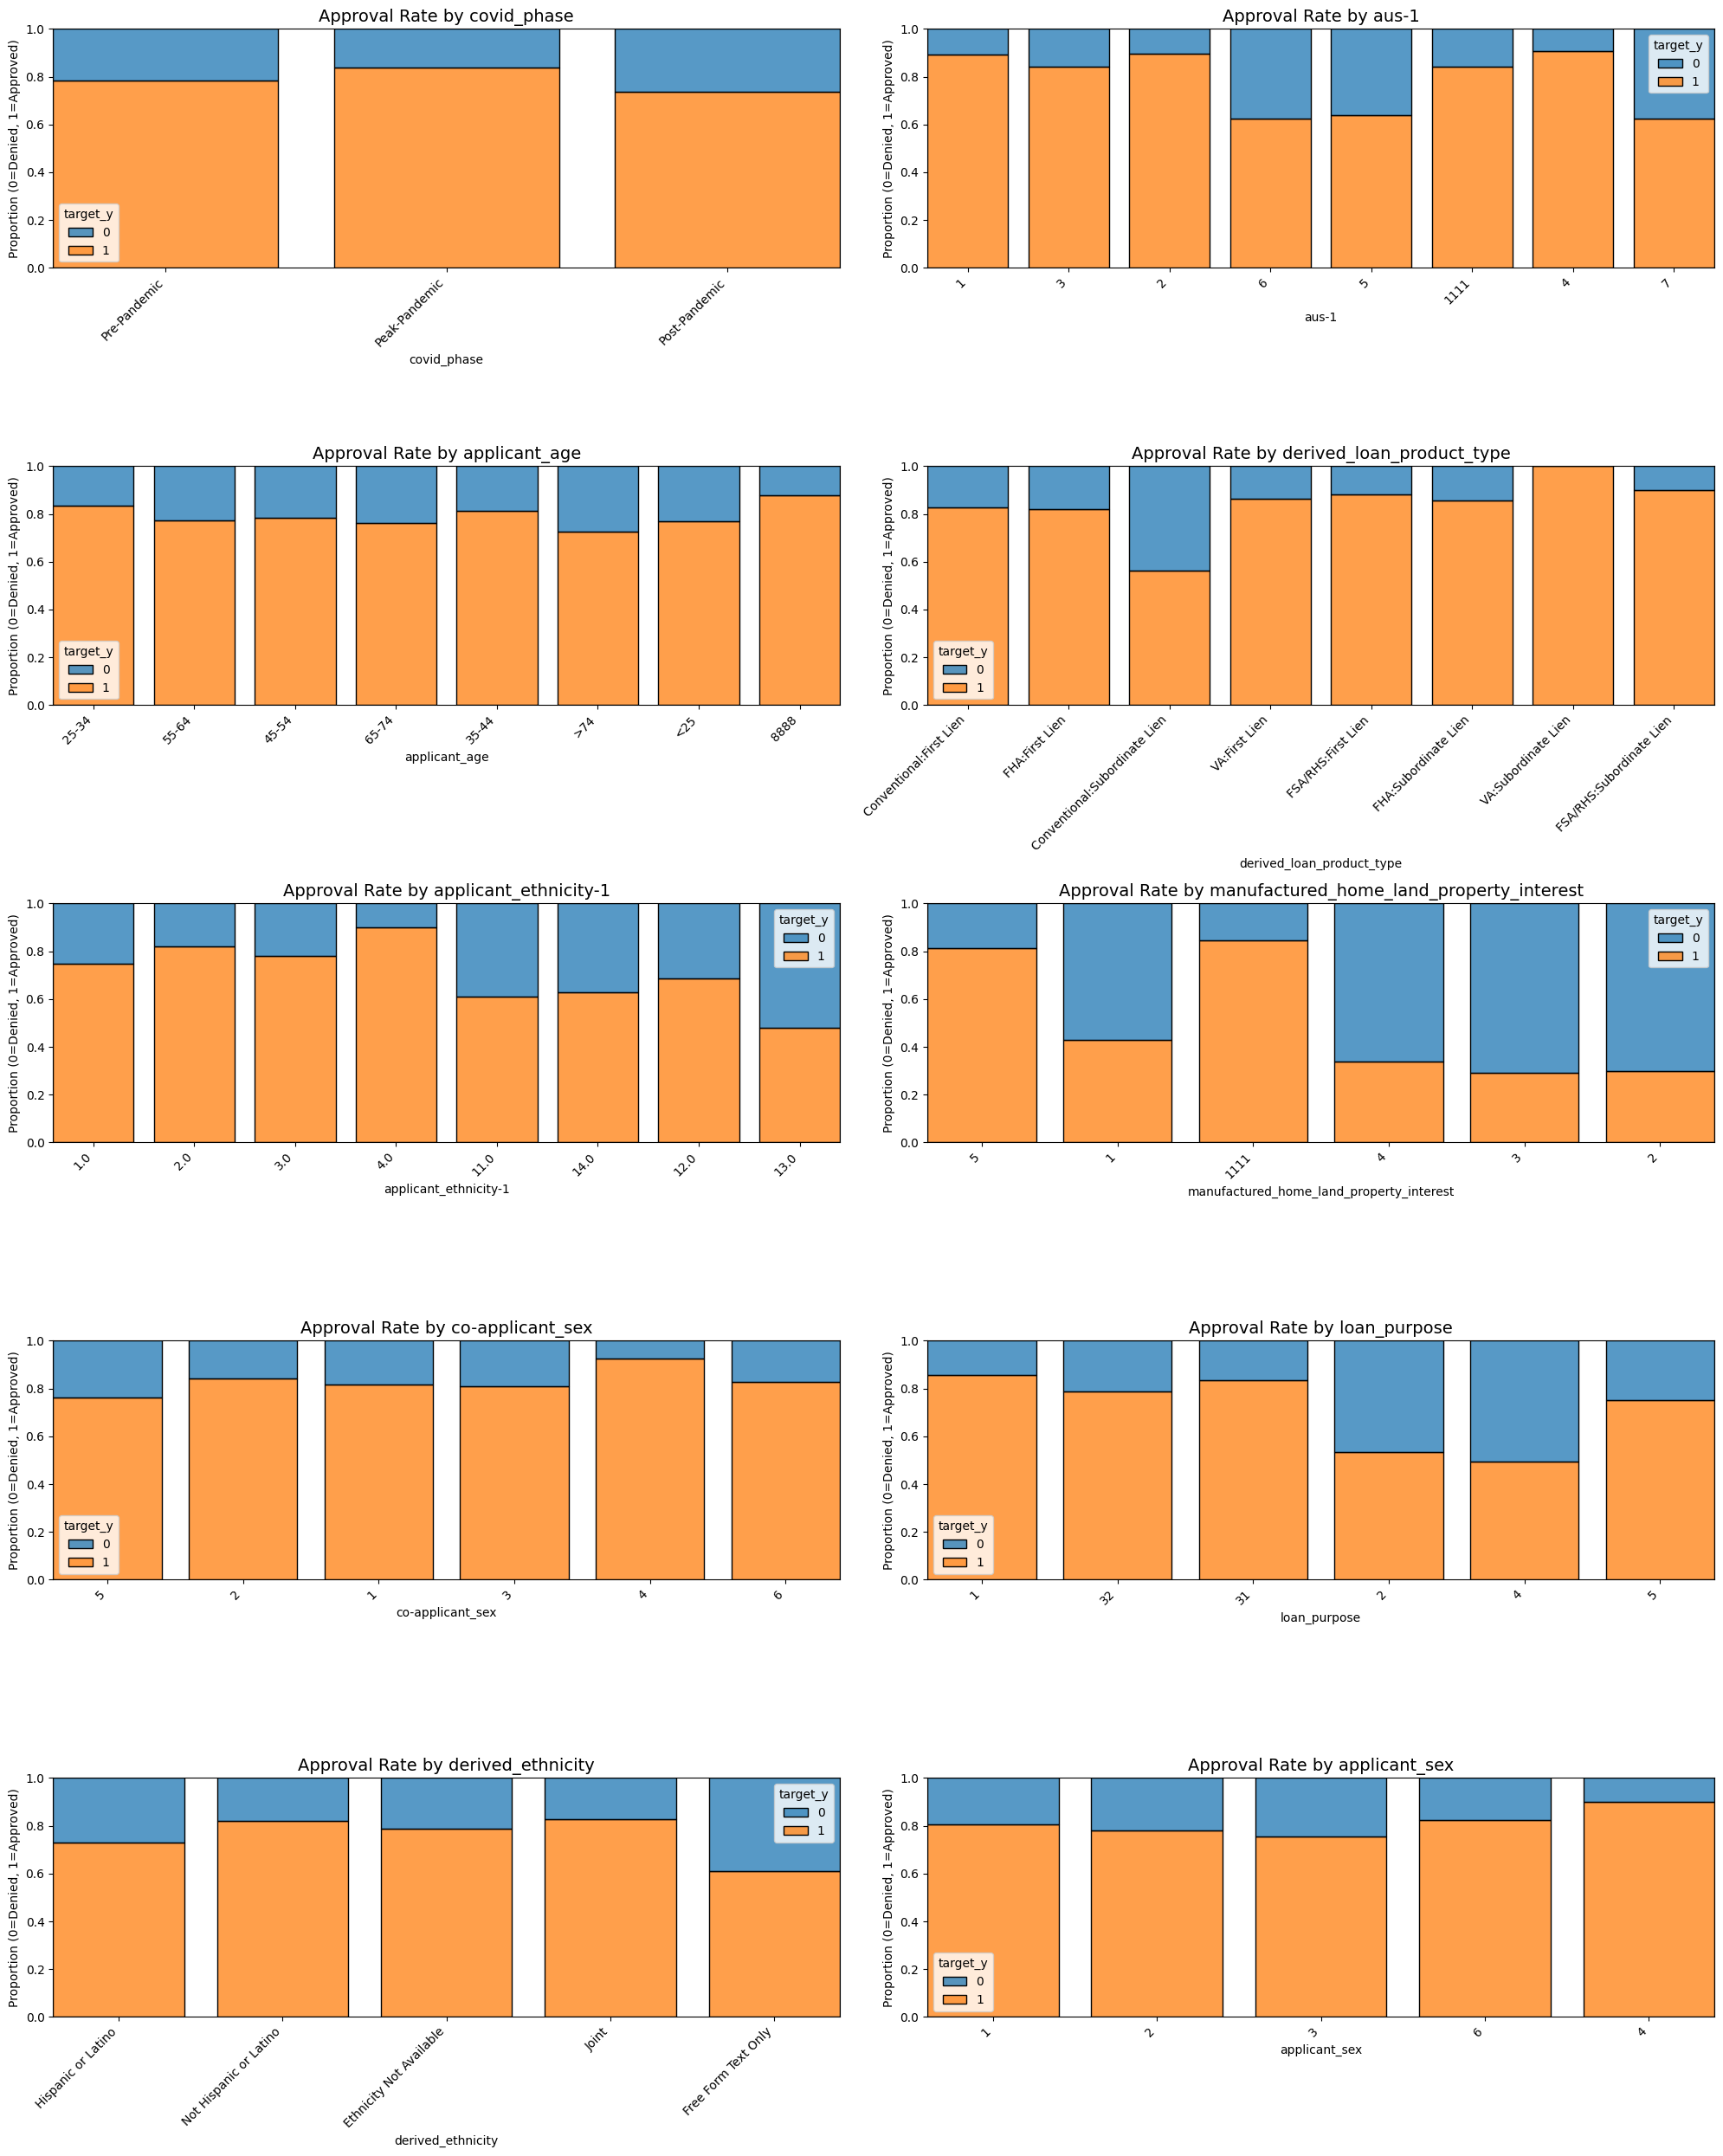

In [71]:
# before plotting, we made a copy of the df to ensure the axis presents as expected
df_plot = df_cleaned.copy()

cols_to_fix = ['aus-1', 'loan_purpose', 'manufactured_home_land_property_interest', 
               'applicant_ethnicity-1', 'applicant_sex', 'co-applicant_sex']

for col in cols_to_fix:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].astype(str)

# 1. Define the 10 variables we want to inspect
target_cols = [
    'covid_phase', 'aus-1', 'applicant_age', 'derived_loan_product_type', 
    'applicant_ethnicity-1', 'manufactured_home_land_property_interest', 
    'co-applicant_sex', 'loan_purpose', 'derived_ethnicity', 'applicant_sex'
]

# 2. Create Visualization to see Impact on Target_Y
print("📊 Generating Approval Rate Analysis by Category...")

plt.figure(figsize=(20, 25))
for i, col in enumerate(target_cols):
    plt.subplot(5, 2, i+1)
    
    # Calculate the approval rate (percentage) for each category
    # target_y=1 is Approved
    order = df_plot[col].value_counts().index
    sns.histplot(data=df_plot, x=col, hue='target_y', multiple="fill", shrink=.8)
    
    plt.title(f'Approval Rate by {col}', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Proportion (0=Denied, 1=Approved)')

plt.tight_layout()
plt.show()

### Analysis

Based on the visual Exploratory Data Analysis (EDA) of approval rates across different categories, we applied a strict evaluation and consolidation strategy to the top 10 categorical features. The goal is to maximize predictive signal while minimizing noise and dimensionality.

#### 1. covid_phase (Macroeconomic Phase)

Observation: The economic phases are already well-segmented, showing distinct and meaningful variances in approval rates across different macroeconomic periods.

Action: Retain without modification.

#### 2. aus-1 (Automated Underwriting System)

Observation: Categories 1, 2, 3, and 4 demonstrate significantly high approval rates (nearly 90%). Conversely, categories 5, 6, 7, and 1111 show a sharp increase in denial rates, with approval dropping to approximately 60%.

Action: Binned into two major classes. Official standard systems (1, 2, 3, 4) are grouped as Standard_AUS, while the rest (5, 6, 7, 1111) are grouped as Non_Standard_or_Exempt.

#### 3. applicant_age (Applicant Age)

Action: Re-binned into broader life-stage categories to capture meaningful demographic trends: <25 is retained, 25-34 and 35-44 are merged into 25-44, and all age groups 45 and above are merged into >44. Placeholder anomaly values (8888 and 9999) are replaced with true missing values (NaN) to facilitate downstream regression imputation.

#### 4.derived_loan_product_type (Loan Product Type)

Observation: Categories containing "First Lien" consistently exhibit approval rates above 80%. In contrast, "Subordinate Lien" categories (especially Conventional loans) experience a drastic drop in approval rates to roughly 50%.

Action: Extracted text patterns to bin into two binary classes: First_Lien and Subordinate_Lien.

#### 5.manufactured_home_land_property_interest (Land Property Interest)

Observation: Categories 5 and 1111 exhibit remarkably high approval rates, whereas categories 1, 2, 3, and 4 show highly inflated denial proportions.

Action: Binned into two major classes. 5 and 1111 are merged into Not_Applicable_or_Exempt, while 1, 2, 3, and 4 are merged into Has_Property_Interest.

#### 6.co-applicant_sex (Co-applicant Presence)

Observation: Category 5 (No co-applicant) has a noticeably lower approval rate compared to the others. The actual gender of the co-applicant shows little to no variance; the critical predictive factor is simply the presence of a co-applicant.

Action: Converted to a binary feature (is_joint_application). Category 5 maps to 0 (Single Application), and all other categories map to 1 (Joint Application).

#### 7.loan_purpose (Loan Purpose)

Observation: Categories 1 (Home purchase), 31 (Refinancing), 32 (Cash-out), and 5 maintain robust approval rates. However, categories 2 (Home improvement) and 4 (Other) face a nearly 50% denial rate.

Action: Binned into two risk profiles: 1, 31, 32, and 5 are grouped as Standard_Purpose, while 2 and 4 are categorized as High_Risk_Purpose.

#### 8.derived_ethnicity (Derived Ethnicity)

Observation: Exhibits noticeable variance across different categories, providing a valid signal for downstream analysis.

Action: Retained without modification to facilitate Fair Lending and bias mitigation analysis.

#### 9.applicant_ethnicity-1 & applicant_sex (Redundant/Zero-Variance Features)

Observation: applicant_ethnicity-1 is entirely redundant with the derived ethnicity column. Furthermore, the visual distribution for applicant_sex displays perfectly flat bar heights across all gender categories, indicating zero predictive value for loan approval.

Action: Dropped both features entirely to reduce dimensionality and multicollinearity.

In [72]:
# 1. covid_phase: Keep as is (Assuming already created in previous steps)

# 2. aus-1: Binning based on sharp visual difference in approval rates
def bin_aus(val):
    val = str(val)
    # 1, 2, 3, 4 show high approval (~90%)
    if val in ['1', '2', '3', '4']: 
        return 'Standard_AUS'
    # 5, 6, 7, 1111 show lower approval (~60-80%)
    else: 
        return 'Non_Standard_or_Exempt'

df_cleaned['aus_grouped'] = df_cleaned['aus-1'].apply(bin_aus)

# 3. applicant_age: Binning into broader groups and setting 8888 to NaN
def bin_age(val):
    val = str(val)
    if val == '<25':
        return '<25'
    elif val in ['25-34', '35-44']:
        return '25-44'
    elif val in ['45-54', '55-64', '65-74', '>74']:
        return '>44'
    elif val in ['8888', '9999']:
        return np.nan
    else:
        return np.nan

df_cleaned['applicant_age_grouped'] = df_cleaned['applicant_age'].apply(bin_age)

# 4. derived_loan_product_type: Binning by Lien status due to massive variance
def bin_loan_product(val):
    val = str(val)
    if 'First Lien' in val:
        return 'First_Lien'
    elif 'Subordinate Lien' in val:
        return 'Subordinate_Lien'
    else:
        return 'Other'

df_cleaned['loan_product_grouped'] = df_cleaned['derived_loan_product_type'].apply(bin_loan_product)

# 5. manufactured_home_land_property_interest: High approval vs High denial grouping
def bin_manufactured_home(val):
    val = str(val)
    # 5 and 1111 have high approval
    if val in ['5', '1111']:
        return 'Not_Applicable_or_Exempt'
    # 1, 2, 3, 4 have significantly higher denial rates
    else:
        return 'Has_Property_Interest'

df_cleaned['manufactured_home_grouped'] = df_cleaned['manufactured_home_land_property_interest'].apply(bin_manufactured_home)

# 6. co-applicant_sex: Grouping by presence of co-applicant (5 = No co-applicant)
df_cleaned['is_joint_application'] = df_cleaned['co-applicant_sex'].astype(str).apply(
    lambda x: 0 if x == '5' else 1
)

# 7. loan_purpose: Binning high-risk purposes (2, 4) vs standard (1, 31, 32, 5)
def bin_loan_purpose(val):
    val = str(val)
    # 2 (Home improvement) and 4 (Other) show ~50% denial
    if val in ['2', '4']:
        return 'High_Risk_Purpose'
    else:
        return 'Standard_Purpose'

df_cleaned['loan_purpose_grouped'] = df_cleaned['loan_purpose'].apply(bin_loan_purpose)

# 8. Drop variables with near-zero variance or redundancy
cols_to_drop = [
    'aus-1',                                    # Replaced by aus_grouped
    'applicant_age',                            # Replaced by applicant_age_grouped
    'derived_loan_product_type',                # Replaced by loan_product_grouped
    'manufactured_home_land_property_interest', # Replaced by manufactured_home_grouped
    'co-applicant_sex',                         # Replaced by is_joint_application
    'loan_purpose',                             # Replaced by loan_purpose_grouped
    'applicant_sex',                            # Dropped: Visually flat approval rates across categories
    'applicant_ethnicity-1'                     # Dropped: Redundant with derived_ethnicity
]

df_final = df_cleaned.drop(columns=cols_to_drop, errors='ignore')

print("--- Data Processing Complete ---")
print(f"Final columns: {df_final.columns.tolist()}")
print(f"Count of NaN in 'applicant_age_grouped' (previously 8888/9999): {df_final['applicant_age_grouped'].isna().sum()}")

--- Data Processing Complete ---
Final columns: ['state_code', 'conforming_loan_limit', 'derived_dwelling_category', 'derived_ethnicity', 'derived_sex', 'preapproval', 'loan_type', 'lien_status', 'reverse_mortgage', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread', 'hoepa_status', 'total_loan_costs', 'origination_charges', 'discount_points', 'lender_credits', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'property_value', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'income', 'applicant_ethnicity_observed', 'co-applicant_ethnicity_observed', 'applicant_race_observed', 'co-applicant_race_observed', 'applicant_sex_observed', 'co-applicant_sex_observed', 'applicant_age_above_62', 'co-applicant_age_above_62', 'submission_of_application', 'initially_payable_to_institution', 'tract_population', 'tract_minority_populatio

In [73]:
print(list(df_final.columns))

['state_code', 'conforming_loan_limit', 'derived_dwelling_category', 'derived_ethnicity', 'derived_sex', 'preapproval', 'loan_type', 'lien_status', 'reverse_mortgage', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread', 'hoepa_status', 'total_loan_costs', 'origination_charges', 'discount_points', 'lender_credits', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'property_value', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'income', 'applicant_ethnicity_observed', 'co-applicant_ethnicity_observed', 'applicant_race_observed', 'co-applicant_race_observed', 'applicant_sex_observed', 'co-applicant_sex_observed', 'applicant_age_above_62', 'co-applicant_age_above_62', 'submission_of_application', 'initially_payable_to_institution', 'tract_population', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income',

In [74]:
df_final.head(3)

,state_code,conforming_loan_limit,derived_dwelling_category,derived_ethnicity,derived_sex,preapproval,loan_type,lien_status,reverse_mortgage,open-end_line_of_credit,...,tract_one_to_four_family_homes,tract_median_age_of_housing_units,target_y,covid_phase,aus_grouped,applicant_age_grouped,loan_product_grouped,manufactured_home_grouped,is_joint_application,loan_purpose_grouped
0,CA,C,Single Family (1-4 Units):Site-Built,Hispanic or Latino,Male,2,1,1,2,2,...,1742,62,1,Pre-Pandemic,Standard_AUS,25-44,First_Lien,Not_Applicable_or_Exempt,0,Standard_Purpose
1,TX,C,Single Family (1-4 Units):Site-Built,Hispanic or Latino,Female,2,2,1,2,2,...,5424,11,1,Pre-Pandemic,Standard_AUS,25-44,First_Lien,Not_Applicable_or_Exempt,0,Standard_Purpose
2,TX,C,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,Male,2,1,1,2,2,...,2696,52,1,Pre-Pandemic,Standard_AUS,25-44,First_Lien,Not_Applicable_or_Exempt,0,Standard_Purpose


## 1.4. Drop Zero / Near-Zero Variance Features(We Split Train & Test Set Here)

In [ ]:
# - For numeric: near-constant columns provide little signal.
# - For categorical: if one category dominates (e.g., 99% same), it's also near-zero variance.
# - To avoid leakage, decide what to drop using TRAIN split only, then apply to all splits.


# 1) Split first (only used to *decide* which columns are low-variance)
X = df_final.drop(columns=['target_y'])
y = df_final['target_y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2) Identify numeric vs categorical columns (based on dtype)
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

# 3) Temporary imputation ONLY for measuring variance / dominance
X_tmp = X_train.copy()

for c in numeric_cols:
    if X_tmp[c].isna().any():
        X_tmp[c] = X_tmp[c].fillna(X_tmp[c].median())

for c in categorical_cols:
    # treat missing as its own value for dominance check; then fill remaining NAs with mode
    s = X_tmp[c].astype('string')
    if s.isna().any():
        mode = s.dropna().mode()
        fill_val = mode.iloc[0] if len(mode) else "<MISSING>"
        s = s.fillna(fill_val)
    X_tmp[c] = s

# 4) Rules
# numeric: std extremely small
NUM_STD_THRESHOLD = 0.03
# categorical: either 1 unique value, or max category proportion too high
CAT_DOMINANCE_THRESHOLD = 0.98

numeric_low_var = []
for c in numeric_cols:
    if float(X_tmp[c].std(ddof=0)) <= NUM_STD_THRESHOLD:
        numeric_low_var.append(c)

categorical_low_var = []
cat_dominance = {}
for c in categorical_cols:
    vc = X_tmp[c].value_counts(normalize=True, dropna=False)
    if len(vc) <= 1:
        categorical_low_var.append(c)
        cat_dominance[c] = float(vc.iloc[0]) if len(vc) else 1.0
        continue
    top = float(vc.iloc[0])
    cat_dominance[c] = top
    if top >= CAT_DOMINANCE_THRESHOLD:
        categorical_low_var.append(c)

cols_to_drop_low_var = sorted(set(numeric_low_var + categorical_low_var))

print("--- Low-variance feature scan (decided on TRAIN only) ---")

# Show what will be dropped (you asked for the 10)
if cols_to_drop_low_var:
    print("\nColumns to drop (showing up to 10):")
    for c in cols_to_drop_low_var[:10]:
        if c in numeric_cols:
            std = float(X_tmp[c].std(ddof=0))
            print(f"  [NUM] {c}: std={std:.6g}")
        else:
            vc = X_tmp[c].value_counts(normalize=True, dropna=False)
            top_share = float(vc.iloc[0]) if len(vc) else 1.0
            n_unique = int(len(vc))
            reason = "1-unique" if n_unique <= 1 else f"top_share>={CAT_DOMINANCE_THRESHOLD}"
            print(f"  [CAT] {c}: {reason}, n_unique={n_unique}, top_share={top_share:.4f}")

    if len(cols_to_drop_low_var) == 10:
        print("\n(Exactly 10 columns will be dropped.)")
    elif len(cols_to_drop_low_var) > 10:
        print(f"\n(There are {len(cols_to_drop_low_var)} columns to drop; increase display by changing [:10] if needed.)")
else:
    print("\nNo low-variance columns found with current thresholds.")

print("\n--- Summary ---")
print("(Counts below are computed on TRAIN only.)")
print("--- Low-variance feature scan (decided on TRAIN only) ---")
print(f"Numeric near-constant cols (std <= {NUM_STD_THRESHOLD}): {len(numeric_low_var)}")
print(f"Categorical near-constant cols (top share >= {CAT_DOMINANCE_THRESHOLD} or 1-unique): {len(categorical_low_var)}")
print(f"TOTAL to drop: {len(cols_to_drop_low_var)}")

--- Low-variance feature scan (decided on TRAIN only) ---

Columns to drop (showing up to 10):
  [CAT] negative_amortization: top_share>=0.98, n_unique=3, top_share=0.9860
  [CAT] other_nonamortizing_features: top_share>=0.98, n_unique=3, top_share=0.9808
  [CAT] preapproval: top_share>=0.98, n_unique=2, top_share=0.9838
  [CAT] reverse_mortgage: top_share>=0.98, n_unique=3, top_share=0.9809

--- Summary ---
(Counts below are computed on TRAIN only.)
--- Low-variance feature scan (decided on TRAIN only) ---
Numeric near-constant cols (std <= 0.03): 0
Categorical near-constant cols (top share >= 0.98 or 1-unique): 4
TOTAL to drop: 4


In [76]:
# 5) Drop from the full dataset (using the TRAIN-decided list)
LOW_VAR_DROP_COLS = cols_to_drop_low_var

df_final_before = df_final.shape
df_final = df_final.drop(columns=LOW_VAR_DROP_COLS, errors='ignore')
print("\n✅ Applied drop to df_final")
print("df_final shape:", df_final_before, "->", df_final.shape)

# Re-create train/test with the reduced feature set for the next steps
X = df_final.drop(columns=['target_y'])
y = df_final['target_y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train/Test shapes:", X_train.shape, X_test.shape)


✅ Applied drop to df_final
df_final shape: (139991, 54) -> (139991, 50)
Train/Test shapes: (111992, 49) (27999, 49)


## 1.5. Imputation

#### viz current missing values via heatmap

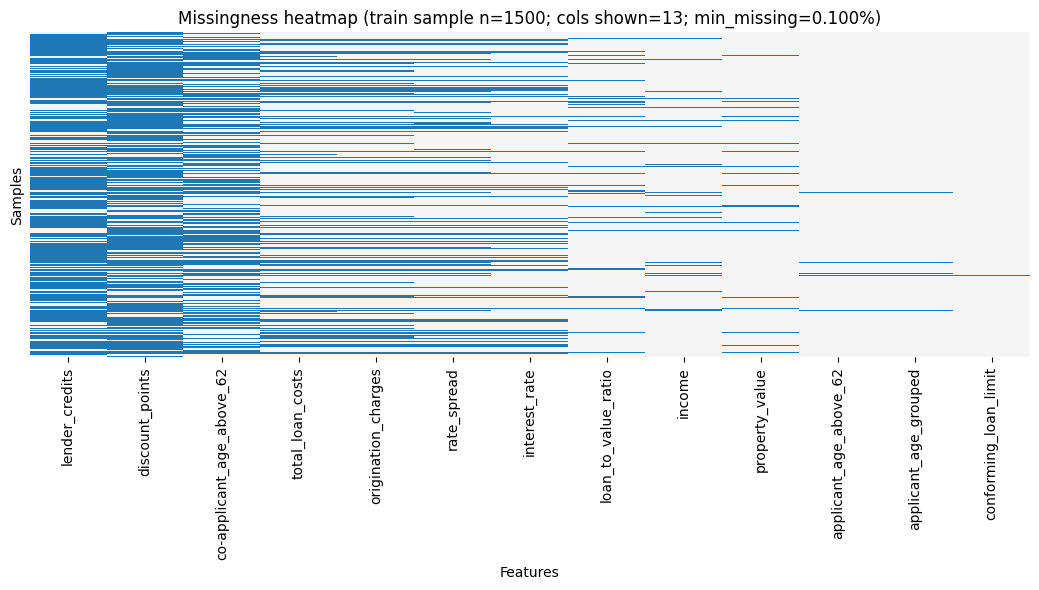

Top missing-rate features shown (train, before imputation) [%]:
lender_credits               72.44
discount_points              71.14
co-applicant_age_above_62    54.06
total_loan_costs             33.17
origination_charges          32.45
rate_spread                  27.73
interest_rate                21.53
loan_to_value_ratio           8.89
income                        7.03
property_value                4.97
applicant_age_above_62        1.50
applicant_age_grouped         1.50
conforming_loan_limit         0.48
dtype: float64


In [ ]:
# --- Missing-value heatmap (train sample) ---
# Only show columns that actually have missing values.

missing_rate = X_train.isna().mean().sort_values(ascending=False)

TOP_K_COLS = 35
HEATMAP_N_ROWS = 1500
MIN_MISSING_RATE = 0.001  # 0.1% (set to 0 to include any missing > 0)

missing_nonzero = missing_rate[missing_rate > 0]
missing_focus = missing_nonzero[missing_nonzero >= MIN_MISSING_RATE]

# If threshold filters everything out, fall back to any non-zero missing
if missing_focus.empty:
    missing_focus = missing_nonzero

cols_show = missing_focus.head(TOP_K_COLS).index.tolist()

if not cols_show:
    print("No missing values found in X_train.")
else:
    X_show = X_train[cols_show]

    if len(X_show) > HEATMAP_N_ROWS:
        X_show = X_show.sample(n=HEATMAP_N_ROWS, random_state=42)

    miss_mat = X_show.isna().astype(int)

    plt.figure(figsize=(min(18, 0.5 * len(cols_show) + 4), 6))
    sns.heatmap(
        miss_mat,
        cmap=sns.color_palette(["#f5f5f5", "#1f77b4"], as_cmap=True),
        cbar=False,
        yticklabels=False,
    )
    plt.title(
        f"Missingness heatmap (train sample n={len(miss_mat)}; cols shown={len(cols_show)}; min_missing={MIN_MISSING_RATE:.3%})"
    )
    plt.xlabel("Features")
    plt.ylabel("Samples")
    plt.tight_layout()
    plt.show()

    print('Top missing-rate features shown (train, before imputation) [%]:')
    print((missing_focus.head(TOP_K_COLS) * 100).round(2))


In [ ]:
# --- Missing-value imputation (fit on train only) ---
# - Numeric: split into mean vs median imputation based on skewness (train)
# - Categorical: mode imputation
# - Regression/iterative imputation for a small set of highly-related cost variables


# sklearn IterativeImputer is experimental


assert isinstance(X_train, pd.DataFrame) and isinstance(X_test, pd.DataFrame)

numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

# 1) Decide mean vs median using TRAIN skewness
skew = X_train[numeric_cols].skew(numeric_only=True).fillna(0.0)
SKEW_ABS_THRESHOLD = 0.75
mean_cols = skew[skew.abs() <= SKEW_ABS_THRESHOLD].index.tolist()
median_cols = [c for c in numeric_cols if c not in mean_cols]

print('--- Imputation plan (decided on TRAIN only) ---')
print('Numeric cols:', len(numeric_cols))
print(f"  mean-impute (|skew| <= {SKEW_ABS_THRESHOLD}):", len(mean_cols))
print(f"  median-impute (|skew| > {SKEW_ABS_THRESHOLD}):", len(median_cols))
print('Categorical cols (mode-impute):', len(categorical_cols))

# 2) Base numeric imputation
imp_mean = SimpleImputer(strategy='mean')
imp_median = SimpleImputer(strategy='median')

X_train_num = X_train[numeric_cols].copy()
X_test_num = X_test[numeric_cols].copy()

if mean_cols:
    X_train_num[mean_cols] = imp_mean.fit_transform(X_train_num[mean_cols])
    X_test_num[mean_cols] = imp_mean.transform(X_test_num[mean_cols])

if median_cols:
    X_train_num[median_cols] = imp_median.fit_transform(X_train_num[median_cols])
    X_test_num[median_cols] = imp_median.transform(X_test_num[median_cols])

# 3) regression/iterative imputation for highly-related numeric variables
#    (This happens AFTER base imputation so the iterative model has a stable starting point.)

def _iterative_impute(block_cols, label):
    cols = [c for c in block_cols if c in X_train_num.columns]
    if len(cols) < 2:
        print(f"Regression/iterative imputation skipped for {label} (need >=2 cols; found {len(cols)}).")
        return

    it_imp = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=15,
        random_state=42,
        sample_posterior=False,
    )
    X_train_num[cols] = it_imp.fit_transform(X_train_num[cols])
    X_test_num[cols] = it_imp.transform(X_test_num[cols])
    print(f"Regression/iterative imputation applied to {label}:", cols)

# Regression imputation 1: costs/fees (mutually informative)
_iterative_impute(
    [
        'total_loan_costs',
        'origination_charges',
        'discount_points',
        'lender_credits',
    ],
    label='costs/fees',
)

# Regression imputation 2: property_value <-> loan_amount <-> income (highly related)
_iterative_impute(
    [
        'property_value',
        'loan_amount',
        'income',
    ],
    label='property/loan/income',
)

# 4) Categorical mode imputation
# NOTE: sklearn SimpleImputer can error on pandas 'string' dtype with pd.NA.
# Convert to object and represent missing as np.nan.
imp_mode = SimpleImputer(strategy='most_frequent')

X_train_cat = X_train[categorical_cols].copy()
X_test_cat = X_test[categorical_cols].copy()

if categorical_cols:
    X_train_cat_obj = X_train_cat.astype('object').where(~X_train_cat.isna(), np.nan)
    X_test_cat_obj = X_test_cat.astype('object').where(~X_test_cat.isna(), np.nan)

    X_train_cat_imp = pd.DataFrame(
        imp_mode.fit_transform(X_train_cat_obj),
        columns=categorical_cols,
        index=X_train_cat.index,
    )
    X_test_cat_imp = pd.DataFrame(
        imp_mode.transform(X_test_cat_obj),
        columns=categorical_cols,
        index=X_test_cat.index,
    )
else:
    X_train_cat_imp = X_train_cat
    X_test_cat_imp = X_test_cat
    
# 5) Recombine back into DataFrames (preserve original column order)
X_train_imputed = pd.concat([X_train_num, X_train_cat_imp], axis=1)[X_train.columns]
X_test_imputed = pd.concat([X_test_num, X_test_cat_imp], axis=1)[X_test.columns]

# Sanity checks
print('\nSanity checks:')
print('Any NA in X_train_imputed?', bool(X_train_imputed.isna().any().any()))
print('Any NA in X_test_imputed? ', bool(X_test_imputed.isna().any().any()))
print('X_train_imputed shape:', X_train_imputed.shape)
print('X_test_imputed shape :', X_test_imputed.shape)


--- Imputation plan (decided on TRAIN only) ---
Numeric cols: 18
  mean-impute (|skew| <= 0.75): 4
  median-impute (|skew| > 0.75): 14
Categorical cols (mode-impute): 31
Regression/iterative imputation applied to costs/fees: ['total_loan_costs', 'origination_charges', 'discount_points', 'lender_credits']
Regression/iterative imputation applied to property/loan/income: ['property_value', 'loan_amount', 'income']

Sanity checks:
Any NA in X_train_imputed? False
Any NA in X_test_imputed?  False
X_train_imputed shape: (111992, 49)
X_test_imputed shape : (27999, 49)


In [82]:
# --- Missingness heatmap (AFTER imputation) ---

assert 'X_train_imputed' in globals() and 'X_test_imputed' in globals()

missing_rate_after = X_train_imputed.isna().mean().sort_values(ascending=False)
missing_nonzero = missing_rate_after[missing_rate_after > 0]

TOP_K_COLS = 35
HEATMAP_N_ROWS = 1500

if missing_nonzero.empty:
    print("✅ After imputation: no missing values in X_train_imputed.")
else:
    cols_show = missing_nonzero.head(TOP_K_COLS).index.tolist()
    X_show = X_train_imputed[cols_show]

    if len(X_show) > HEATMAP_N_ROWS:
        X_show = X_show.sample(n=HEATMAP_N_ROWS, random_state=42)

    miss_mat = X_show.isna().astype(int)

    plt.figure(figsize=(min(18, 0.5 * len(cols_show) + 4), 6))
    sns.heatmap(
        miss_mat,
        cmap=sns.color_palette(["#f5f5f5", "#d62728"], as_cmap=True),
        cbar=False,
        yticklabels=False,
    )
    plt.title(f"Missingness heatmap AFTER imputation (train sample n={len(miss_mat)}; cols shown={len(cols_show)})")
    plt.xlabel("Features")
    plt.ylabel("Samples")
    plt.tight_layout()
    plt.show()

    print('Still-missing features after imputation (train) [%]:')
    print((missing_nonzero.head(TOP_K_COLS) * 100).round(4))


✅ After imputation: no missing values in X_train_imputed.


## 1.6. OHE

In [80]:
# --- One-Hot Encoding---
# - For binary categorical features, use drop='if_binary' so you get a single 0/1 column. Here we only set the state as binary, whereas CA=0，TX=1
# - For numeric features that are really binary coded as {1,2}, map them to {0,1}.


# Use the imputed dataframes from the previous cell
assert 'X_train_imputed' in globals() and 'X_test_imputed' in globals()

X_train_enc_in = X_train_imputed.copy()
X_test_enc_in = X_test_imputed.copy()

# Make ONLY state_code binary (CA vs TX)
STATE_COL = 'state_code'
STATE_BIN_COL = 'state_code_bin'

if STATE_COL in X_train_enc_in.columns:
    train_states = pd.Series(X_train_enc_in[STATE_COL].dropna().unique()).astype(str).tolist()
    if len(train_states) != 2:
        raise ValueError(f"Expected {STATE_COL} to have exactly 2 values in TRAIN, got {len(train_states)}: {train_states}")

    # stable mapping: CA->0, TX->1 (alphabetical)
    states_sorted = sorted(train_states)
    state_to_bin = {states_sorted[0]: 0, states_sorted[1]: 1}

    X_train_enc_in[STATE_BIN_COL] = X_train_enc_in[STATE_COL].astype(str).map(state_to_bin).astype('int8')
    X_test_enc_in[STATE_BIN_COL] = X_test_enc_in[STATE_COL].astype(str).map(state_to_bin).astype('int8')

    X_train_enc_in = X_train_enc_in.drop(columns=[STATE_COL])
    X_test_enc_in = X_test_enc_in.drop(columns=[STATE_COL])

    print(f"Mapped {STATE_COL} -> {STATE_BIN_COL}:", state_to_bin)

# Recompute numeric/categorical after state binarization
numeric_cols = X_train_enc_in.select_dtypes(include=['number']).columns.tolist()
categorical_cols = [c for c in X_train_enc_in.columns if c not in numeric_cols]

# OHE categorical; drop one level if binary to get single 0/1 column
# Also force sparse output.
ohe = OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=True)

encoder = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', ohe, categorical_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
    sparse_threshold=1.0,
)

X_train_ohe = encoder.fit_transform(X_train_enc_in)
X_test_ohe = encoder.transform(X_test_enc_in)

print('Encoded shapes:')
print('X_train_ohe:', X_train_ohe.shape)
print('X_test_ohe :', X_test_ohe.shape)

# Optional: feature names (can be large)
try:
    feat_names = encoder.get_feature_names_out()
    print('Total features after OHE:', len(feat_names))
    print('First 30 feature names:', list(feat_names[:30]))
except Exception as e:
    print('Could not extract feature names:', e)

# Sanity check: no NaNs in sparse matrix
if hasattr(X_train_ohe, 'data'):
    print('Any NaNs in encoded train data?', bool(np.isnan(X_train_ohe.data).any()))


Mapped state_code -> state_code_bin: {'CA': 0, 'TX': 1}
Encoded shapes:
X_train_ohe: (111992, 103)
X_test_ohe : (27999, 103)
Total features after OHE: 103
First 30 feature names: ['loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread', 'total_loan_costs', 'origination_charges', 'discount_points', 'lender_credits', 'property_value', 'income', 'tract_population', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage', 'tract_owner_occupied_units', 'tract_one_to_four_family_homes', 'tract_median_age_of_housing_units', 'is_joint_application', 'state_code_bin', 'conforming_loan_limit_C', 'conforming_loan_limit_NC', 'conforming_loan_limit_U', 'derived_dwelling_category_Multifamily:Manufactured', 'derived_dwelling_category_Multifamily:Site-Built', 'derived_dwelling_category_Single Family (1-4 Units):Manufactured', 'derived_dwelling_category_Single Family (1-4 Units):Site-Built', 'derived_ethnicity_Ethnicity Not Available', 'der

In [81]:
# ！！！for test & intepretation in further parts only, a quick tranformation to get a overview of the cleaned dataset
# feature_names = encoder.get_feature_names_out()

# X_train_mat = X_train_ohe
# X_test_mat = X_test_ohe

# if isinstance(X_train_mat, np.ndarray):
#     X_train_mat = sparse.csr_matrix(X_train_mat)
# if isinstance(X_test_mat, np.ndarray):
#     X_test_mat = sparse.csr_matrix(X_test_mat)

# X_train_ohe_df = pd.DataFrame.sparse.from_spmatrix(
#     X_train_mat, index=X_train_imputed.index, columns=feature_names
# )
# train_out = X_train_ohe_df.copy()
# train_out["target_y"] = y_train.values
# train_out.to_csv("X_train_ohe.csv", index=False)

# X_test_ohe_df = pd.DataFrame.sparse.from_spmatrix(
#     X_test_mat, index=X_test_imputed.index, columns=feature_names
# )
# test_out = X_test_ohe_df.copy()
# test_out["target_y"] = y_test.values
# train_out.sample(2000, random_state=42).to_csv("X_train_ohe_sample2000.csv", index=False)